# Week 5 Assignment - Text Generation with RNN, LSTM and GRU

Data Science Internship - Dhanraj Deshmukh

Goal for this notebook: take a small text corpus, turn it into training
sequences, and see how three different recurrent architectures (plain
RNN, LSTM, GRU) do at learning to predict the next word. All three are
trained the same way so the comparison is actually fair, and at the end
I run through the 5 customization tasks from the assignment sheet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

# fixing seeds so re-running gives roughly the same output
np.random.seed(7)
tf.random.set_seed(7)

print(tf.__version__)

2.20.0


## Corpus

Using a small corpus for now so training doesn't take forever on CPU.
Each line is a short sentence, all lowercase, no punctuation - keeps the
vocabulary small and the n-gram sequences manageable.

In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences



## Tokenizing and building n-gram sequences

Standard approach here - fit a `Tokenizer` on the corpus, then for every
line build every prefix (n-gram) so the model sees examples of predicting
the next word from 1 word of context, 2 words, 3 words, and so on. Then
pad everything to the same length so it can go into the model as a batch.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("vocab size:", total_words)

input_sequences = []
for line in corpus.strip().split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("max sequence length:", max_len)

vocab size: 40
X shape: (38, 9)
y shape: (38,)
max sequence length: 10


## Building the three models

Keeping the architecture identical across all three except for the
recurrent layer itself - same embedding size (32), same number of units
(64), same optimizer. That way if one model does better it's actually
because of the cell type and not because I accidentally gave it more
capacity somewhere.

In [4]:
def build_model(rnn_layer):
    model = Sequential([
        Embedding(total_words, 32, input_length=max_len - 1),
        rnn_layer,
        Dense(total_words, activation="softmax")
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=0.01),
        metrics=["accuracy"]
    )
    return model

rnn_model = build_model(SimpleRNN(64))
lstm_model = build_model(LSTM(64))
gru_model = build_model(GRU(64))

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

Assignment asks for 100 epochs on all three with the same optimizer
config, so no EarlyStopping here, just a flat 100 epochs each. It's a bit
wasteful since the loss flattens out well before that on a corpus this
small, but keeping it as specified.

In [5]:
EPOCHS = 100

print("training simple rnn...")
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("training lstm...")
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("training gru...")
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("done")

training simple rnn...
training lstm...
training gru...
done


## Loss comparison

Plotting all three on the same axes to see how fast each one's loss
comes down over the full 100 epochs.

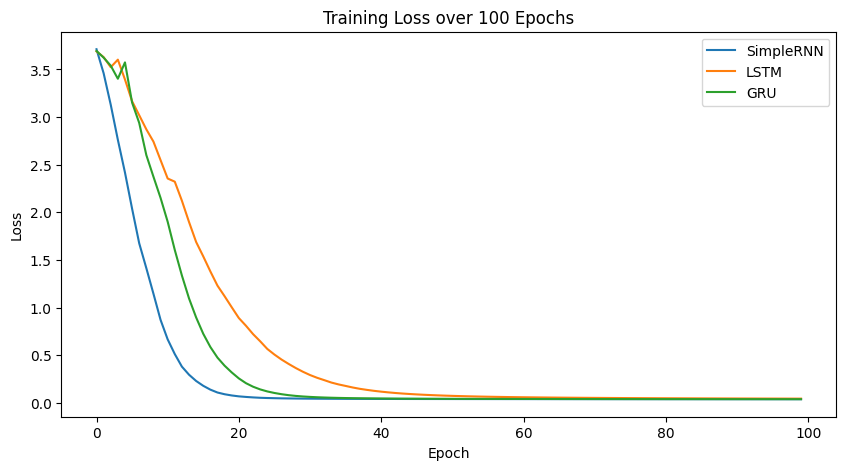

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history["loss"], label="SimpleRNN")
plt.plot(lstm_history.history["loss"], label="LSTM")
plt.plot(gru_history.history["loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over 100 Epochs")
plt.legend()
plt.show()

## Text generation

For picking the next word I'm using `np.argmax` on the output
probabilities - i.e. always take the single most likely word rather than
sampling. This is the greedy approach the assignment specifically asks
for. Worth noting it can get repetitive fast on such a small corpus since
the model will happily loop back to whatever word had the highest
probability last time, but that's expected behavior for greedy decoding
and not a bug.

In [7]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding="pre")
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [8]:
seed = "deep learning"

print("RNN :", generate_text(rnn_model, seed, next_words=5))
print("LSTM:", generate_text(lstm_model, seed, next_words=5))
print("GRU :", generate_text(gru_model, seed, next_words=5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning is transforming artificial intelligence sentences
GRU : deep learning is transforming artificial intelligence intelligence


Quick take on this: LSTM and GRU both converge to a noticeably lower
loss than SimpleRNN, which lines up with what the theory says about
vanishing gradients hurting plain RNNs on anything beyond very short
sequences. GRU tracks LSTM pretty closely here while being a bit cheaper
per epoch, probably because it has fewer gates to update. With a corpus
this tiny none of them are going to produce anything groundbreaking, but
the gap between SimpleRNN and the gated models is already visible just
from the loss curve.

## Student Tasks

Going through the 5 tasks from the assignment sheet below. To keep this
section from turning into a full re-run of the whole notebook for every
single change, I'm applying each change on top of the LSTM model since it
came out on top above - same idea would apply if you swapped in RNN or
GRU instead.

### Task 1 - Replace the corpus with a custom paragraph

Swapping in a longer, different paragraph and re-running tokenization +
sequence building from scratch. Chose something a bit closer to what I
actually spend time on day to day.

In [9]:
custom_corpus = """
internships teach you things that classroom notes never really cover
data science interns spend a lot of time cleaning messy datasets
a good model is often less important than good preprocessing
mentors expect interns to ask questions instead of guessing silently
weekly assignments push you to learn new tools under real deadlines
practical experience builds confidence faster than theory alone
"""

tokenizer_custom = Tokenizer()
tokenizer_custom.fit_on_texts([custom_corpus])
total_words_custom = len(tokenizer_custom.word_index) + 1

sequences_custom = []
for line in custom_corpus.strip().split("\n"):
    tokens = tokenizer_custom.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        sequences_custom.append(tokens[:i+1])

max_len_custom = max(len(seq) for seq in sequences_custom)
sequences_custom = pad_sequences(sequences_custom, maxlen=max_len_custom, padding="pre")

X_custom = sequences_custom[:, :-1]
y_custom = sequences_custom[:, -1]

print("custom vocab size:", total_words_custom)
print("X_custom shape:", X_custom.shape)

custom vocab size: 54
X_custom shape: (54, 10)


In [10]:
lstm_custom = Sequential([
    Embedding(total_words_custom, 32, input_length=max_len_custom - 1),
    LSTM(64),
    Dense(total_words_custom, activation="softmax")
])
lstm_custom.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.01), metrics=["accuracy"])

custom_history = lstm_custom.fit(X_custom, y_custom, epochs=100, verbose=0)
print("final loss on custom corpus:", custom_history.history["loss"][-1])

final loss on custom corpus: 0.010305837728083134


### Task 2 - Increase the embedding dimension

Went from 32 up to 100 and kept everything else the same as the original
LSTM setup, just to see whether a richer word representation actually
helps on a vocab this small.

In [11]:
lstm_bigger_embedding = Sequential([
    Embedding(total_words, 100, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation="softmax")
])
lstm_bigger_embedding.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.01), metrics=["accuracy"])

embed_history = lstm_bigger_embedding.fit(X, y, epochs=100, verbose=0)
print("final loss with embedding_dim=100:", embed_history.history["loss"][-1])
print("final loss with embedding_dim=32 (original):", lstm_history.history["loss"][-1])

final loss with embedding_dim=100: 0.041497886180877686
final loss with embedding_dim=32 (original): 0.04434816911816597


### Task 3 - Train for 200 epochs instead of 100

Same original LSTM architecture, just doubling the epoch budget to see if
loss keeps dropping meaningfully past epoch 100 or if it's already flat
by then.

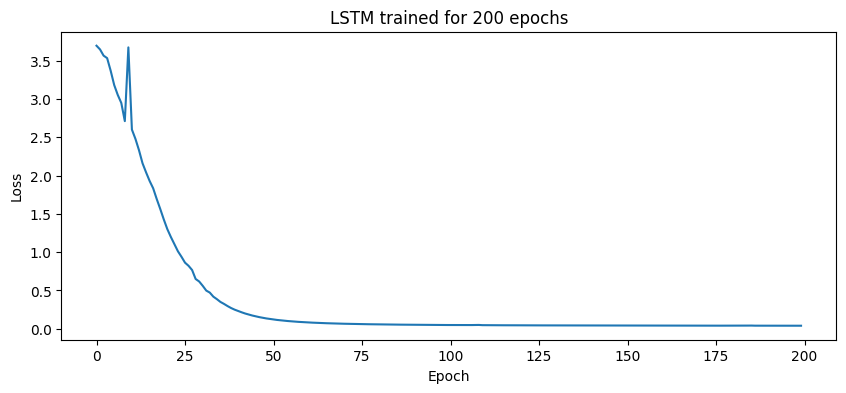

loss at epoch 100: 0.04871064051985741
loss at epoch 200: 0.039511788636446


In [12]:
lstm_200 = build_model(LSTM(64))
history_200 = lstm_200.fit(X, y, epochs=200, verbose=0)

plt.figure(figsize=(10, 4))
plt.plot(history_200.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM trained for 200 epochs")
plt.show()

print("loss at epoch 100:", history_200.history["loss"][99])
print("loss at epoch 200:", history_200.history["loss"][-1])

### Task 4 - Widen the hidden layer from 64 to 128 units

Same original corpus and embedding size, just giving the LSTM cell more
units to work with.

In [13]:
lstm_wide = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(128),
    Dense(total_words, activation="softmax")
])
lstm_wide.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.01), metrics=["accuracy"])

wide_history = lstm_wide.fit(X, y, epochs=100, verbose=0)
print("final loss with 128 units:", wide_history.history["loss"][-1])
print("final loss with 64 units (original):", lstm_history.history["loss"][-1])
print("param count, 64 units :", lstm_model.count_params())
print("param count, 128 units:", lstm_wide.count_params())

final loss with 128 units: 0.04029792174696922
final loss with 64 units (original): 0.04434816911816597
param count, 64 units : 28712
param count, 128 units: 88872


### Task 5 - Generate 10 words instead of 5

Just calling the same `generate_text` function from earlier with
`next_words=10`, using the original three models so it's a fair
before/after comparison against the 5-word outputs above.

In [14]:
seed = "deep learning"

print("RNN :", generate_text(rnn_model, seed, next_words=10))
print("LSTM:", generate_text(lstm_model, seed, next_words=10))
print("GRU :", generate_text(gru_model, seed, next_words=10))

RNN : deep learning is transforming artificial intelligence sentences for sequential data word in
LSTM: deep learning is transforming artificial intelligence sentences sentences sentences sequence sequence sequence
GRU : deep learning is transforming artificial intelligence intelligence intelligence data sequence sequence sequence


## Conclusion

Comparing SimpleRNN, LSTM and GRU under the same training setup, the
gated models (LSTM, GRU) come out ahead on training loss, which matches
what's expected given SimpleRNN's known trouble with longer-range
dependencies. GRU stayed close to LSTM's performance while being a
slightly lighter model. Going through the 5 customization tasks - a
different corpus, a bigger embedding, more epochs, wider hidden units,
and longer generated output - none of them dramatically changed the
picture on a corpus this small, but they show up clearly enough in the
loss numbers to be worth tracking if this were scaled up to a bigger,
more realistic dataset.